### Random Forest Algorithm using Tensorflow

##### Απαραίτητες Βιβλιοθήκες

In [1]:
import tensorflow_decision_forests as tfdf

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print("Found TensorFlow Decision Forests v" + tfdf.__version__)

2024-02-29 20:45:25.381877: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-29 20:45:25.381963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-29 20:45:25.402872: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-29 20:45:25.450984: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-29 20:45:26.399951: W tensorflow/compiler/tf2

Found TensorFlow Decision Forests v1.8.1


##### Διάβασμα dataset και Δημιουργία Dataframe

In [2]:
path_train = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/train data.csv"  
train_data = pd.read_csv(path_train, delimiter=';')

path_test = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/test data.csv"  
test_data = pd.read_csv(path_test, delimiter=';')

label_column = "class" 

tf_train_dataset = tfdf.keras.pd_dataframe_to_tf_dataset(train_data, label=label_column)
tf_test_dataset = tfdf.keras.pd_dataframe_to_tf_dataset(test_data, label=label_column)

train_data.rename(columns={'range 1': 'range_1', 'range 2': 'range_2', 'range 3': 'range_3', 'range 4': 'range_4'}, inplace=True)
test_data.rename(columns={'range 1': 'range_1', 'range 2': 'range_2', 'range 3': 'range_3', 'range 4': 'range_4'}, inplace=True)

2024-02-29 20:45:28.283266: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-29 20:45:28.411612: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-29 20:45:28.416521: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

##### Train το Μοντέλο

In [3]:
model_rf = tfdf.keras.RandomForestModel(verbose=0)
model_rf.fit(tf_train_dataset, validation_data=tf_test_dataset)

#model_rf.summary()

Num validation examples: tf.Tensor(100, shape=(), dtype=int32)


[INFO 24-02-29 20:45:32.3771 EET kernel.cc:1233] Loading model from path /tmp/tmp0knq4til/model/ with prefix 6961a1d2e64344c1
[INFO 24-02-29 20:45:32.3944 EET decision_forest.cc:660] Model loaded with 300 root(s), 7624 node(s), and 30 input feature(s).
[INFO 24-02-29 20:45:32.3944 EET abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-02-29 20:45:32.3945 EET kernel.cc:1061] Use fast generic engine


In [4]:
inspector = model_rf.make_inspector()
importances = inspector.variable_importances()

print("Variable Importances:")
for variable, importance in importances.items():
    print(f"{variable}: {importance}")

Variable Importances:
INV_MEAN_MIN_DEPTH: [("range_3" (1; #29), 0.2906421428065502), ("range_2" (1; #28), 0.26190346385072244), ("range_4" (1; #30), 0.25426609720873733), ("range_1" (1; #27), 0.2521360519278209), ("I1MIN" (1; #2), 0.22073932625632628), ("I2VAR" (1; #7), 0.21950819807534638), ("I1VAR" (1; #3), 0.2085086241303701), ("I1" (1; #0), 0.2081324478067766), ("I2MIN" (1; #6), 0.20377696970381096), ("I3var" (1; #11), 0.20255967223249602), ("I2" (1; #4), 0.19982764833946892), ("Vdcmax1" (1; #23), 0.1924512777226497), ("I4" (1; #12), 0.19214231024097655), ("I3" (1; #8), 0.19195454834826703), ("I4MIN" (1; #14), 0.19033387315208058), ("Vdcmin1" (1; #25), 0.19000145442967104), ("T" (1; #22), 0.18949863094330707), ("I3max" (1; #9), 0.18940447002822045), ("Pdcmean1" (1; #21), 0.1893139156719629), ("Vdcmean1" (1; #24), 0.18901139677375323), ("Itotalmax1" (1; #19), 0.1887890651518098), ("I2MAX" (1; #5), 0.18877308380979507), ("I6" (1; #16), 0.18866701972265001), ("Itotalmin1" (1; #20), 0.

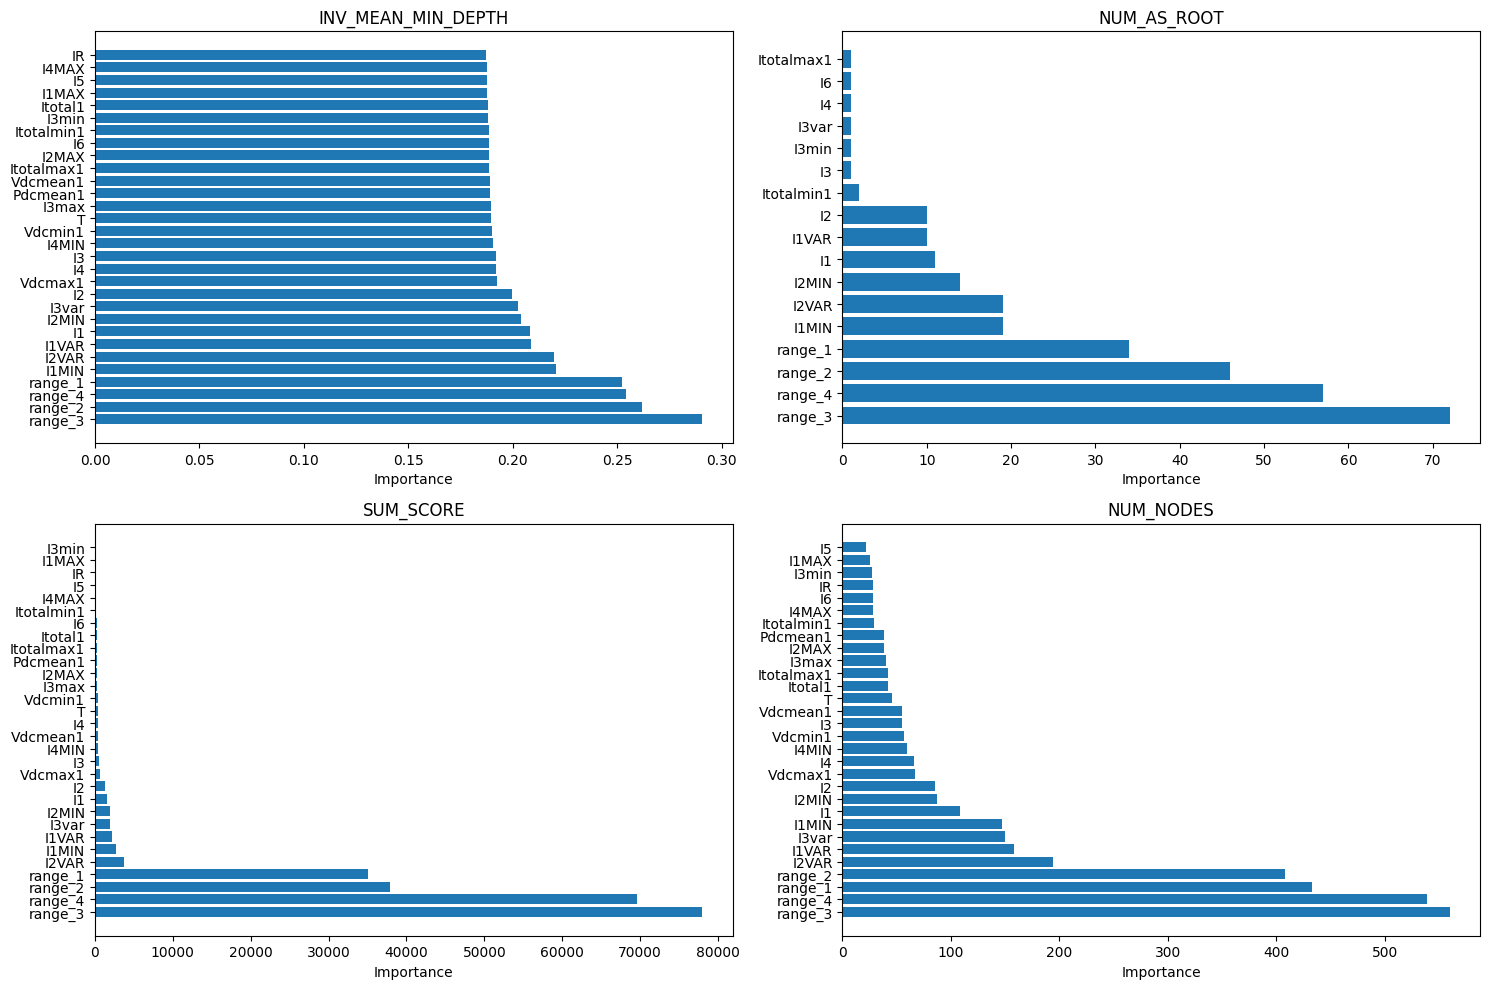

In [5]:
import matplotlib.pyplot as plt
import numpy as np

inspector = model_rf.make_inspector()
importances = inspector.variable_importances()

inv_mean_min_depth = importances["INV_MEAN_MIN_DEPTH"]
num_as_root = importances["NUM_AS_ROOT"]
sum_score = importances["SUM_SCORE"]
num_nodes = importances["NUM_NODES"]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Plot for INV_MEAN_MIN_DEPTH
axs[0, 0].barh(range(len(inv_mean_min_depth)), [imp[1] for imp in inv_mean_min_depth], align="center")
axs[0, 0].set_yticks(range(len(inv_mean_min_depth)))
axs[0, 0].set_yticklabels([imp[0].name for imp in inv_mean_min_depth])
axs[0, 0].set_xlabel("Importance")
axs[0, 0].set_title("INV_MEAN_MIN_DEPTH")

# Plot for NUM_AS_ROOT
axs[0, 1].barh(range(len(num_as_root)), [imp[1] for imp in num_as_root], align="center")
axs[0, 1].set_yticks(range(len(num_as_root)))
axs[0, 1].set_yticklabels([imp[0].name for imp in num_as_root])
axs[0, 1].set_xlabel("Importance")
axs[0, 1].set_title("NUM_AS_ROOT")

# Plot for SUM_SCORE
axs[1, 0].barh(range(len(sum_score)), [imp[1] for imp in sum_score], align="center")
axs[1, 0].set_yticks(range(len(sum_score)))
axs[1, 0].set_yticklabels([imp[0].name for imp in sum_score])
axs[1, 0].set_xlabel("Importance")
axs[1, 0].set_title("SUM_SCORE")

# Plot for NUM_NODES
axs[1, 1].barh(range(len(num_nodes)), [imp[1] for imp in num_nodes], align="center")
axs[1, 1].set_yticks(range(len(num_nodes)))
axs[1, 1].set_yticklabels([imp[0].name for imp in num_nodes])
axs[1, 1].set_xlabel("Importance")
axs[1, 1].set_title("NUM_NODES")

plt.tight_layout()
plt.show()


##### Αξιολόγηση Μοντέλου

In [44]:
model_rf.compile(metrics=["accuracy"]) 
evaluation = model_rf.evaluate(tf_test_dataset, return_dict=True)
print()

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")

1/1 [==============================] - 0s 110ms/step - loss: 0.0000e+00 - accuracy: 0.9100

loss: 0.0000
accuracy: 0.9100


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Assuming your model is set up for multiclass classification
predictions = model_rf.predict(tf_test_dataset)
true_labels = np.concatenate([y.numpy() for x, y in tf_test_dataset])
predictions_flat = np.argmax(predictions, axis=1)

# Precision, Recall, and F1 Score
precision = precision_score(true_labels, predictions_flat, average='weighted')
recall = recall_score(true_labels, predictions_flat, average='weighted')
f1 = f1_score(true_labels, predictions_flat, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions_flat)
print("Confusion Matrix:")
print(conf_matrix)

1/1 [==============================] - 0s 61ms/step
Precision: 0.9203
Recall: 0.9100
F1 Score: 0.9089
Confusion Matrix:
[[25  0  0  0]
 [ 7 18  0  0]
 [ 0  2 23  0]
 [ 0  0  0 25]]


##### Self-Evaluation

In [ ]:
model_rf.make_inspector().evaluation()

Evaluation(num_examples=600, accuracy=1.0, loss=0.03632503500363479, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

#### Plot το Μοντέλο

In [ ]:
model_rf.make_inspector().training_logs()

[TrainLog(num_trees=1, evaluation=Evaluation(num_examples=218, accuracy=1.0, loss=0.0, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=11, evaluation=Evaluation(num_examples=594, accuracy=0.9814814814814815, loss=0.17545171917387933, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=21, evaluation=Evaluation(num_examples=600, accuracy=0.9983333333333333, loss=0.051918042687078315, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=31, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.04453899348154664, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=41, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.04127508372068405, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=52, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.039300764805326856, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees

1/1 [==============================] - 0s 85ms/step - loss: 0.0000e+00 - accuracy: 0.9100


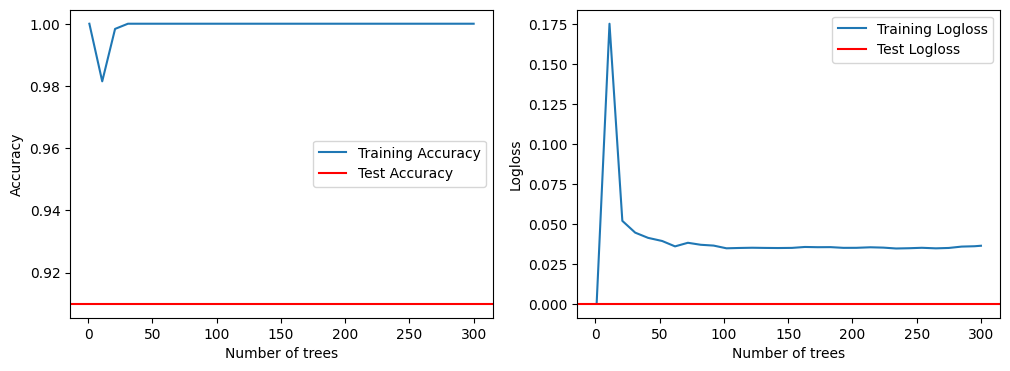

In [ ]:
import matplotlib.pyplot as plt

train_logs = model_rf.make_inspector().training_logs()
evaluation = model_rf.evaluate(tf_test_dataset, return_dict=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.accuracy for log in train_logs], label='Training Accuracy')
plt.axhline(evaluation['accuracy'], color='red', linestyle='-', label='Test Accuracy')
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.loss for log in train_logs], label='Training Logloss')
plt.axhline(evaluation['loss'], color='red', linestyle='-', label='Test Logloss')
plt.xlabel("Number of trees")
plt.ylabel("Logloss")
plt.legend()

plt.show()

### Tensorboard

In [ ]:
# This cell start TensorBoard that can be slow.
# Load the TensorBoard notebook extension
%load_ext tensorboard
# Google internal version
# %load_ext google3.learning.brain.tensorboard.notebook.extension


In [ ]:
# Clear existing results (if any)
#rm -fr "/tmp/tensorboard_logs"

In [ ]:
# Export the meta-data to tensorboard.
model_rf.make_inspector().export_to_tensorboard("/tmp/tensorboard_logs")

In [ ]:
# docs_infra: no_execute
# Start a tensorboard instance.
%tensorboard --logdir "/tmp/tensorboard_logs"

Reusing TensorBoard on port 6006 (pid 13248), started 0:33:58 ago. (Use '!kill 13248' to kill it.)

#### Re-train the model with a different dataset(Range_1, Range_2, Range_3, Range_4)

In [38]:
selected_features = ["range_1", "range_2", "range_3", "range_4", label_column]

train_data_selected = train_data[selected_features]
test_data_selected = test_data[selected_features]

tf_train_dataset_2 = tfdf.keras.pd_dataframe_to_tf_dataset(train_data_selected, label=label_column)
tf_test_dataset_2 = tfdf.keras.pd_dataframe_to_tf_dataset(test_data_selected, label=label_column)

model_rf_2 = tfdf.keras.RandomForestModel(verbose=0)
model_rf_2.fit(tf_train_dataset_2, validation_data=tf_test_dataset_2)

Num validation examples: tf.Tensor(100, shape=(), dtype=int32)


[INFO 24-02-29 21:19:27.3491 EET kernel.cc:1233] Loading model from path /tmp/tmpcaves0co/model/ with prefix e81553b403f24dc5
[INFO 24-02-29 21:19:27.3537 EET decision_forest.cc:660] Model loaded with 300 root(s), 2352 node(s), and 4 input feature(s).
[INFO 24-02-29 21:19:27.3538 EET abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-02-29 21:19:27.3538 EET kernel.cc:1061] Use fast generic engine


In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

model_rf_2.compile(metrics=["accuracy"]) 
evaluation = model_rf_2.evaluate(tf_test_dataset_2, return_dict=True)
print()

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")

predictions = model_rf_2.predict(tf_test_dataset_2)
true_labels = np.concatenate([y.numpy() for x, y in tf_test_dataset_2])
predictions_flat = np.argmax(predictions, axis=1)

# Precision, Recall, and F1 Score
precision = precision_score(true_labels, predictions_flat, average='weighted')
recall = recall_score(true_labels, predictions_flat, average='weighted')
f1 = f1_score(true_labels, predictions_flat, average='weighted')

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions_flat)
print("Confusion Matrix:")
print(conf_matrix)


1/1 [==============================] - 0s 74ms/step - loss: 0.0000e+00 - accuracy: 0.9500

loss: 0.0000
accuracy: 0.9500
1/1 [==============================] - 0s 21ms/step

Precision: 0.9583
Recall: 0.9500
F1 Score: 0.9495
Confusion Matrix:
[[25  0  0  0]
 [ 5 20  0  0]
 [ 0  0 25  0]
 [ 0  0  0 25]]


#### Plot το Μοντέλο

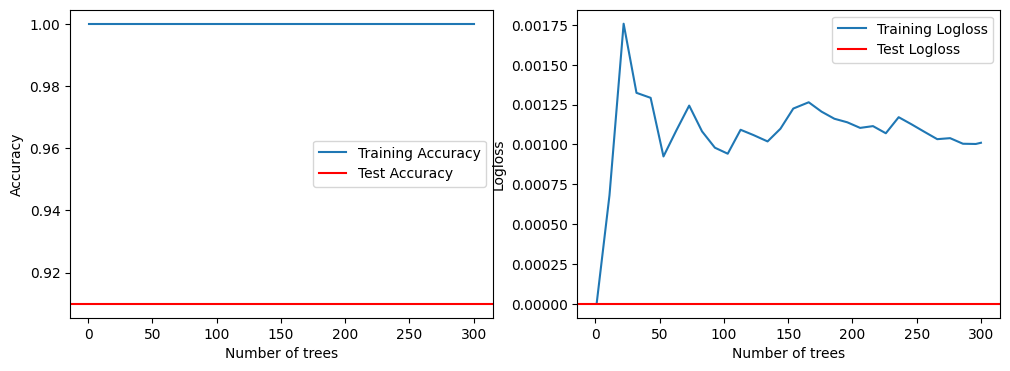

In [ ]:
import matplotlib.pyplot as plt

train_logs = model_rf_2.make_inspector().training_logs()
#evaluation = model_rf_2.evaluate(tf_test_dataset, return_dict=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.accuracy for log in train_logs], label='Training Accuracy')
plt.axhline(evaluation['accuracy'], color='red', linestyle='-', label='Test Accuracy')
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.loss for log in train_logs], label='Training Logloss')
plt.axhline(evaluation['loss'], color='red', linestyle='-', label='Test Logloss')
plt.xlabel("Number of trees")
plt.ylabel("Logloss")
plt.legend()

plt.show()

### Tensorboard

In [ ]:
# This cell start TensorBoard that can be slow.
# Load the TensorBoard notebook extension
%load_ext tensorboard
# Google internal version
# %load_ext google3.learning.brain.tensorboard.notebook.extension

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
# Clear existing results (if any)
#rm -fr "/tmp/tensorboard_logs"

In [ ]:
# Export the meta-data to tensorboard.
model_rf_2.make_inspector().export_to_tensorboard("/tmp/tensorboard_logs2")

In [ ]:
# docs_infra: no_execute
# Start a tensorboard instance.
%tensorboard --logdir "/tmp/tensorboard_logs2"

Reusing TensorBoard on port 6007 (pid 13448), started 0:33:55 ago. (Use '!kill 13448' to kill it.)